# CreditPilot — Stress Simulation Engine

## Overview
This notebook implements a Stress Simulation Engine to evaluate how changes in financial conditions impact a borrower's risk profile.

The system simulates real-world scenarios such as:
- Increase in interest rates  
- Reduction in income  
- Additional loan burden  

This helps assess financial resilience and repayment sustainability.

---

## Objectives

- Simulate adverse financial conditions  
- Recalculate EMI, DTI, and FSI  
- Analyze how risk changes under stress  
- Compare before vs after scenarios  

---

## Key Concept

Even financially stable borrowers can become risky under changing conditions.  
This module helps predict **future risk**, not just current risk.

---

## Outcome

- Stress-adjusted risk score  
- Updated FSI  
- Risk transition (e.g., Low → High)  

---

## Next Step

Streamlit App Integration

In [1]:
import pandas as pd
import numpy as np
import joblib

In [2]:
raw_df = pd.read_csv("../data/raw/creditpilot_dataset.csv")
processed_df = pd.read_csv("../data/processed/final_dataset.csv")

model = joblib.load("../models/final_model.pkl")
scaler = joblib.load("../models/scaler.pkl")

## Base Prediction

In [3]:
X = processed_df.drop("loan_status", axis=1)

prob = model.predict_proba(X)[:, 1]

raw_df["base_probability"] = prob

## Define FSI Function

In [4]:
def calculate_fsi(df):
    credit_norm = (df["credit_score"] - 300) / (850 - 300)

    dti_score = (1 - df["debt_to_income_ratio"])
    emi_score = (1 - df["emi_to_income_ratio"])
    util_score = (1 - df["credit_utilization_ratio"])

    fsi = (
        0.25 * df["income_stability_score"]/100 +
        0.20 * credit_norm +
        0.20 * dti_score +
        0.15 * emi_score +
        0.20 * util_score
    ) * 100

    return fsi

## Base FSI

In [5]:
raw_df["base_fsi"] = calculate_fsi(raw_df)

## Stress Simulation

In [6]:
stress_df = raw_df.copy()

In [7]:
# Apply stress
stress_df["annual_income"] *= 0.8
stress_df["interest_rate"] += 2

In [8]:
# Recalculate EMI
monthly_rate = stress_df["interest_rate"] / (12 * 100)

stress_df["emi"] = (
    stress_df["loan_amount"] * monthly_rate *
    (1 + monthly_rate) ** stress_df["loan_term_months"]
) / (
    (1 + monthly_rate) ** stress_df["loan_term_months"] - 1
)

In [9]:
# Recalculate ratios
stress_df["emi_to_income_ratio"] = stress_df["emi"] / (stress_df["annual_income"] / 12)
stress_df["debt_to_income_ratio"] = stress_df["total_debt"] / stress_df["annual_income"]

## New Model Prediction

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_emp = LabelEncoder()
le_loan = LabelEncoder()

stress_df["employment_type"] = le_emp.fit_transform(stress_df["employment_type"])
stress_df["loan_type"] = le_loan.fit_transform(stress_df["loan_type"])

In [14]:
stress_df["emi_to_income_ratio"] = stress_df["emi"] / (stress_df["annual_income"] / 12)
stress_df["loan_to_income_ratio"] = stress_df["loan_amount"] / stress_df["annual_income"]
stress_df["debt_to_income_ratio"] = stress_df["total_debt"] / stress_df["annual_income"]

In [15]:
stress_df["credit_risk_score"] = (
    (850 - stress_df["credit_score"]) * 0.4 +
    stress_df["debt_to_income_ratio"] * 100 * 0.3 +
    stress_df["credit_utilization_ratio"] * 100 * 0.3
)

In [16]:
stress_input = stress_df.drop(
    columns=["user_id", "loan_status", "base_probability", "base_fsi"]
)

In [17]:
stress_input = stress_input[processed_df.drop("loan_status", axis=1).columns]

In [18]:
stress_scaled = scaler.transform(stress_input)

stress_prob = model.predict_proba(stress_scaled)[:, 1]

stress_df["stress_probability"] = stress_prob

## Comparision

In [20]:
stress_df["stress_fsi"] = calculate_fsi(stress_df)

comparison = pd.DataFrame({
    "base_prob": raw_df["base_probability"],
    "stress_prob": stress_df["stress_probability"],
    "base_fsi": raw_df["base_fsi"],
    "stress_fsi": stress_df["stress_fsi"]
})

comparison.head()

,base_prob,stress_prob,base_fsi,stress_fsi
0,0.075247,0.741125,62.032943,55.918005
1,0.007892,0.190840,45.660147,40.607036
2,0.996996,0.997792,55.546176,50.351138
3,0.954731,0.999750,35.538143,26.622190
4,0.999979,0.999987,21.552588,9.948706


## Risk Change

In [21]:
comparison["risk_change"] = comparison["stress_prob"] - comparison["base_prob"]

## Visualization

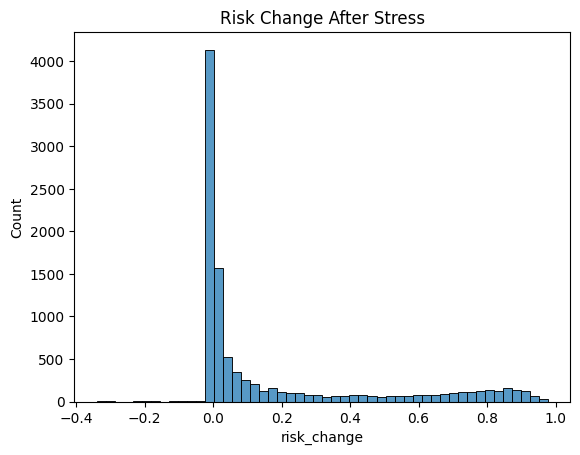

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(comparison["risk_change"], bins=50)
plt.title("Risk Change After Stress")
plt.show()

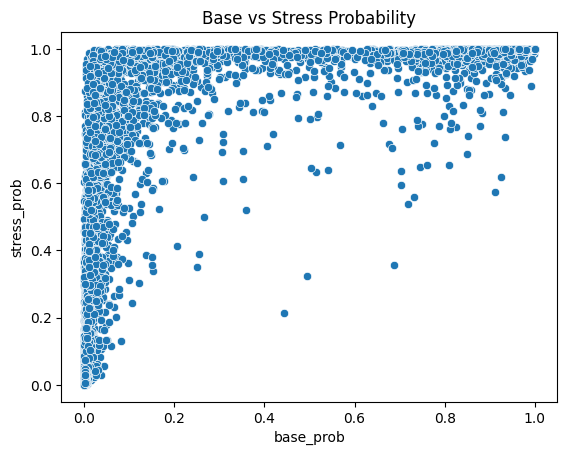

In [23]:
sns.scatterplot(
    x=comparison["base_prob"],
    y=comparison["stress_prob"]
)
plt.title("Base vs Stress Probability")
plt.show()